#  Classification Binaire — Potabilité de l'Eau
### Modèle : XGBoost

**Pipeline :**
1. Chargement & pré-traitement
2. Séparation Train / Validation (80/20)
3. Rééquilibrage SMOTE + Scaling
4. Entraînement XGBoost
5. Prédictions sur l'ensemble de validation
6. Métriques d'évaluation & visualisations

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from scipy.stats.mstats import winsorize

# Modélisation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SEED   = 42
np.random.seed(SEED)
C_NEG  = '#F44336'   # Non potable
C_POS  = '#2196F3'   # Potable

print(f'XGBoost  : {xgb.__version__}')
print(f'Pandas   : {pd.__version__}')
print(f'NumPy    : {np.__version__}')

XGBoost  : 3.2.0
Pandas   : 2.3.3
NumPy    : 2.4.4


---
## 2. Chargement

In [2]:
df = pd.read_csv('water_potability_clean.csv')
print(f'Dimensions brutes   : {df.shape}')
print(f'Valeurs manquantes  :\n{df.isnull().sum()}')
df.head()

Dimensions brutes   : (3276, 10)
Valeurs manquantes  :
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.035456,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.389426,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.389426,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
features = [c for c in df.columns if c != 'Potability']

---
## 3. Séparation Train / Validation

In [4]:
X = df[features]
y = df['Potability']

# Split stratifié 80 / 20
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size    = 0.20,
    stratify     = y,
    random_state = SEED
)

print('┌─────────────────────────────────────────┐')
print('│         RÉPARTITION DES DONNÉES         │')
print('├─────────────────────────────────────────┤')
print(f'│  Train      : {len(X_train):4d} échantillons  '
      f'({y_train.mean()*100:.1f}% potable)  │')
print(f'│  Validation : {len(X_val):4d} échantillons  '
      f'({y_val.mean()*100:.1f}% potable)  │')
print('└─────────────────────────────────────────┘')

┌─────────────────────────────────────────┐
│         RÉPARTITION DES DONNÉES         │
├─────────────────────────────────────────┤
│  Train      : 2620 échantillons  (39.0% potable)  │
│  Validation :  656 échantillons  (39.0% potable)  │
└─────────────────────────────────────────┘


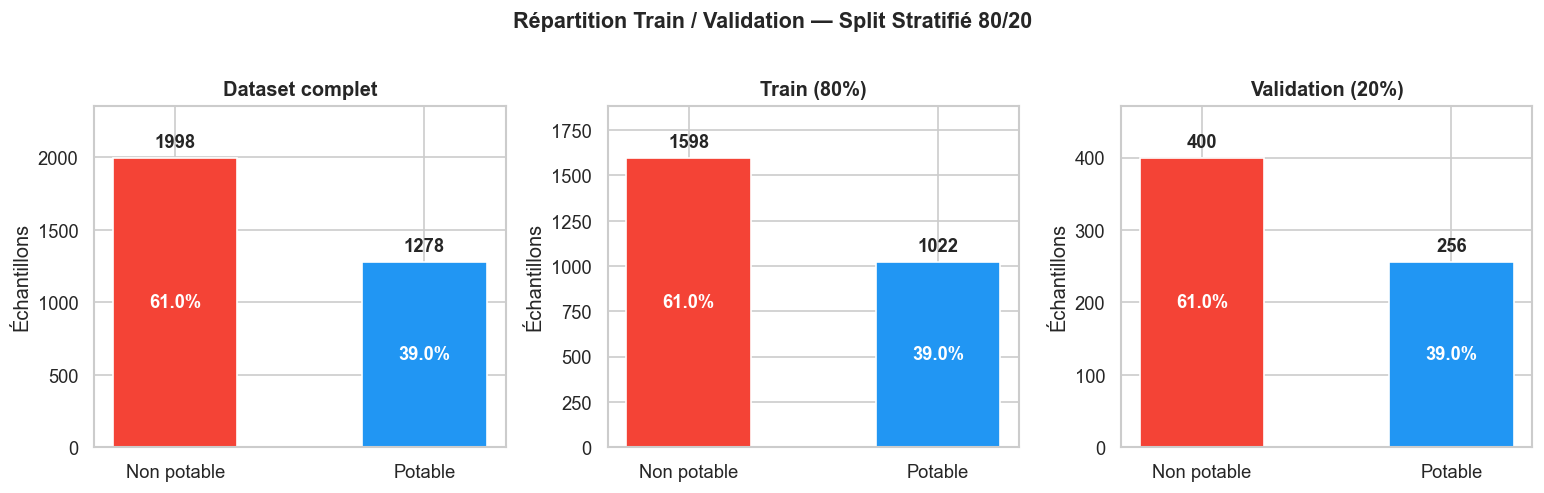

In [5]:
# Visualisation de la répartition
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
splits  = [('Dataset complet', y), ('Train (80%)', y_train), ('Validation (20%)', y_val)]
palette = [C_NEG, C_POS]

for ax, (title, series) in zip(axes, splits):
    counts = series.value_counts().sort_index()
    bars   = ax.bar(['Non potable', 'Potable'], counts.values,
                    color=palette, edgecolor='white', width=0.5)
    ax.bar_label(bars, padding=4, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Échantillons')
    ax.set_ylim(0, counts.max() * 1.18)
    for i, (cnt, total) in enumerate(zip(counts.values, [len(series)]*2)):
        ax.text(i, cnt / 2, f'{cnt/total*100:.1f}%',
                ha='center', va='center', color='white', fontweight='bold')

plt.suptitle('Répartition Train / Validation — Split Stratifié 80/20',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Pré-processing Pipeline (Scaling + SMOTE)

In [6]:
# ── RobustScaler : résistant aux outliers résiduels
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit sur train uniquement
X_val_sc   = scaler.transform(X_val)          # transform sur val

# ── SMOTE : rééquilibrage appliqué sur le train uniquement (jamais sur val)
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print('Pipeline Scaling + SMOTE :')
print(f'  Avant SMOTE → {dict(pd.Series(y_train).value_counts().sort_index())}')
print(f'  Après SMOTE → {dict(pd.Series(y_train_res).value_counts().sort_index())}')
print(f'  Dimension train finale : {X_train_res.shape}')
print(f'  Dimension val (inchangée) : {X_val_sc.shape}')

Pipeline Scaling + SMOTE :
  Avant SMOTE → {0: np.int64(1598), 1: np.int64(1022)}
  Après SMOTE → {0: np.int64(1598), 1: np.int64(1598)}
  Dimension train finale : (3196, 9)
  Dimension val (inchangée) : (656, 9)


---
## 5. Entraînement XGBoost

In [7]:
# Hyperparamètres
params = dict(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    gamma            = 0.1,
    reg_alpha        = 0.1,    # régularisation L1
    reg_lambda       = 1.0,    # régularisation L2
    eval_metric      = 'logloss',
    random_state     = SEED,
    n_jobs           = -1,
)

print('Hyperparamètres XGBoost :')
for k, v in params.items():
    print(f'  {k:25s}: {v}')

Hyperparamètres XGBoost :
  n_estimators             : 500
  max_depth                : 6
  learning_rate            : 0.05
  subsample                : 0.8
  colsample_bytree         : 0.8
  min_child_weight         : 3
  gamma                    : 0.1
  reg_alpha                : 0.1
  reg_lambda               : 1.0
  eval_metric              : logloss
  random_state             : 42
  n_jobs                   : -1


In [8]:
model = xgb.XGBClassifier(**params)

model.fit(
    X_train_res, y_train_res,
    eval_set = [(X_train_res, y_train_res), (X_val_sc, y_val)],
    verbose  = False,
)

print('Entraînement terminé')
print(f'   Nombre d\'arbres entraînés : {model.n_estimators}')

Entraînement terminé
   Nombre d'arbres entraînés : 500


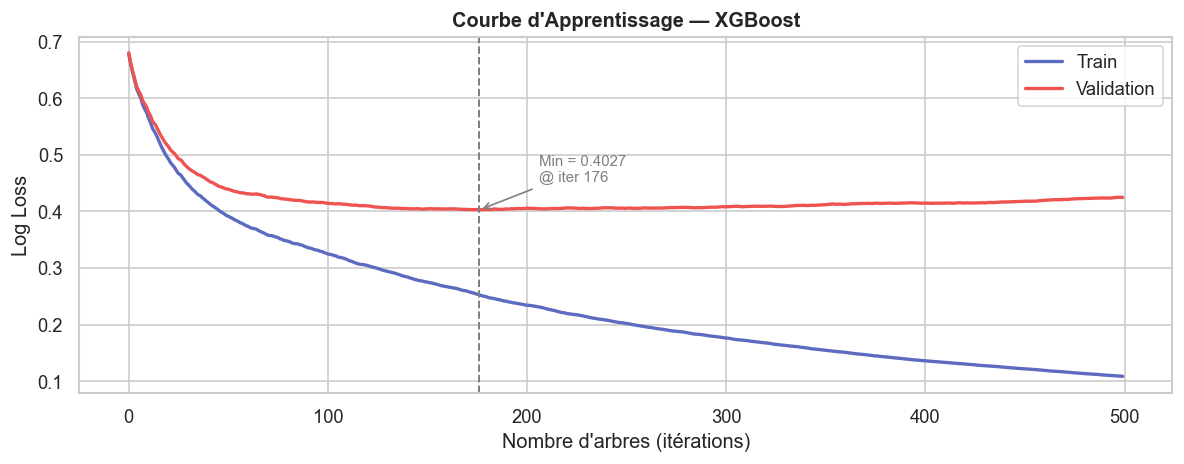

In [9]:
# Courbe d'apprentissage (logloss train vs val)
results = model.evals_result()
epochs  = len(results['validation_0']['logloss'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(results['validation_0']['logloss'], color='#5C6BC0', lw=2, label='Train')
ax.plot(results['validation_1']['logloss'], color='#EF5350', lw=2, label='Validation')
ax.set_xlabel('Nombre d\'arbres (itérations)')
ax.set_ylabel('Log Loss')
ax.set_title('Courbe d\'Apprentissage — XGBoost', fontweight='bold')
ax.legend()
min_val = min(results['validation_1']['logloss'])
best_it = results['validation_1']['logloss'].index(min_val)
ax.axvline(best_it, color='gray', linestyle='--', lw=1.2,
           label=f'Min val @ iter {best_it}')
ax.annotate(f'Min = {min_val:.4f}\n@ iter {best_it}',
            xy=(best_it, min_val), xytext=(best_it+30, min_val+0.05),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')
plt.tight_layout()
plt.show()

---
## 6. Prédictions sur l'Ensemble de Validation

In [10]:
# Prédictions classes et probabilités
y_pred      = model.predict(X_val_sc)
y_pred_prob = model.predict_proba(X_val_sc)[:, 1]

# Aperçu des prédictions
pred_df = pd.DataFrame({
    'Réel'              : y_val.values,
    'Prédit'            : y_pred,
    'Proba (potable)'   : y_pred_prob.round(4),
    'Correct'           : (y_val.values == y_pred)
})

print(f'Total prédit potable     : {y_pred.sum()} / {len(y_pred)}')
print(f'Total réel potable       : {y_val.sum()} / {len(y_val)}')
print(f'\nAperçu des prédictions (10 premiers) :')
pred_df.head(10)

Total prédit potable     : 253 / 656
Total réel potable       : 256 / 656

Aperçu des prédictions (10 premiers) :


,Réel,Prédit,Proba (potable),Correct
0,1,1,0.9907,True
1,0,0,0.0329,True
2,0,0,0.0148,True
3,0,0,0.2434,True
4,0,0,0.0873,True
5,0,0,0.0213,True
6,0,0,0.0956,True
7,0,0,0.3018,True
8,1,0,0.2928,False
9,1,1,0.9357,True


---
## 7. Métriques d'Évaluation

In [11]:
# ─── Calcul de toutes les métriques ───
metrics = {
    'Accuracy'              : accuracy_score(y_val, y_pred),
    'F1-Score'              : f1_score(y_val, y_pred),
    'Précision'             : precision_score(y_val, y_pred),
    'Rappel (Recall)'       : recall_score(y_val, y_pred),
    'ROC-AUC'               : roc_auc_score(y_val, y_pred_prob),
    'Avg Precision (PR-AUC)': average_precision_score(y_val, y_pred_prob),
}

# Validation croisée 5-fold sur le train
cv_scores = cross_val_score(
    xgb.XGBClassifier(**params), X_train_res, y_train_res,
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'roc_auc',
    n_jobs  = -1
)

print('╔══════════════════════════════════════════════╗')
print('║    MÉTRIQUES D\'ÉVALUATION — VALIDATION SET  ║')
print('╠══════════════════════════════════════════════╣')
for name, val in metrics.items():
    bar   = '█' * int(val * 20)
    empty = '░' * (20 - int(val * 20))
    print(f'║  {name:24s}: {val:.4f}  {bar}{empty} ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  CV ROC-AUC (5-fold)   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}         ║')
print('╚══════════════════════════════════════════════╝')

╔══════════════════════════════════════════════╗
║    MÉTRIQUES D'ÉVALUATION — VALIDATION SET  ║
╠══════════════════════════════════════════════╣
║  Accuracy                : 0.7881  ███████████████░░░░░ ║
║  F1-Score                : 0.7269  ██████████████░░░░░░ ║
║  Précision               : 0.7312  ██████████████░░░░░░ ║
║  Rappel (Recall)         : 0.7227  ██████████████░░░░░░ ║
║  ROC-AUC                 : 0.8765  █████████████████░░░ ║
║  Avg Precision (PR-AUC)  : 0.8395  ████████████████░░░░ ║
╠══════════════════════════════════════════════╣
║  CV ROC-AUC (5-fold)   : 0.8965 ± 0.0030         ║
╚══════════════════════════════════════════════╝


In [12]:
# Rapport de classification détaillé
print('═'*55)
print('      RAPPORT DE CLASSIFICATION COMPLET')
print('═'*55)
print(classification_report(
    y_val, y_pred,
    target_names=['Non potable (0)', 'Potable (1)']
))

═══════════════════════════════════════════════════════
      RAPPORT DE CLASSIFICATION COMPLET
═══════════════════════════════════════════════════════
                 precision    recall  f1-score   support

Non potable (0)       0.82      0.83      0.83       400
    Potable (1)       0.73      0.72      0.73       256

       accuracy                           0.79       656
      macro avg       0.78      0.78      0.78       656
   weighted avg       0.79      0.79      0.79       656



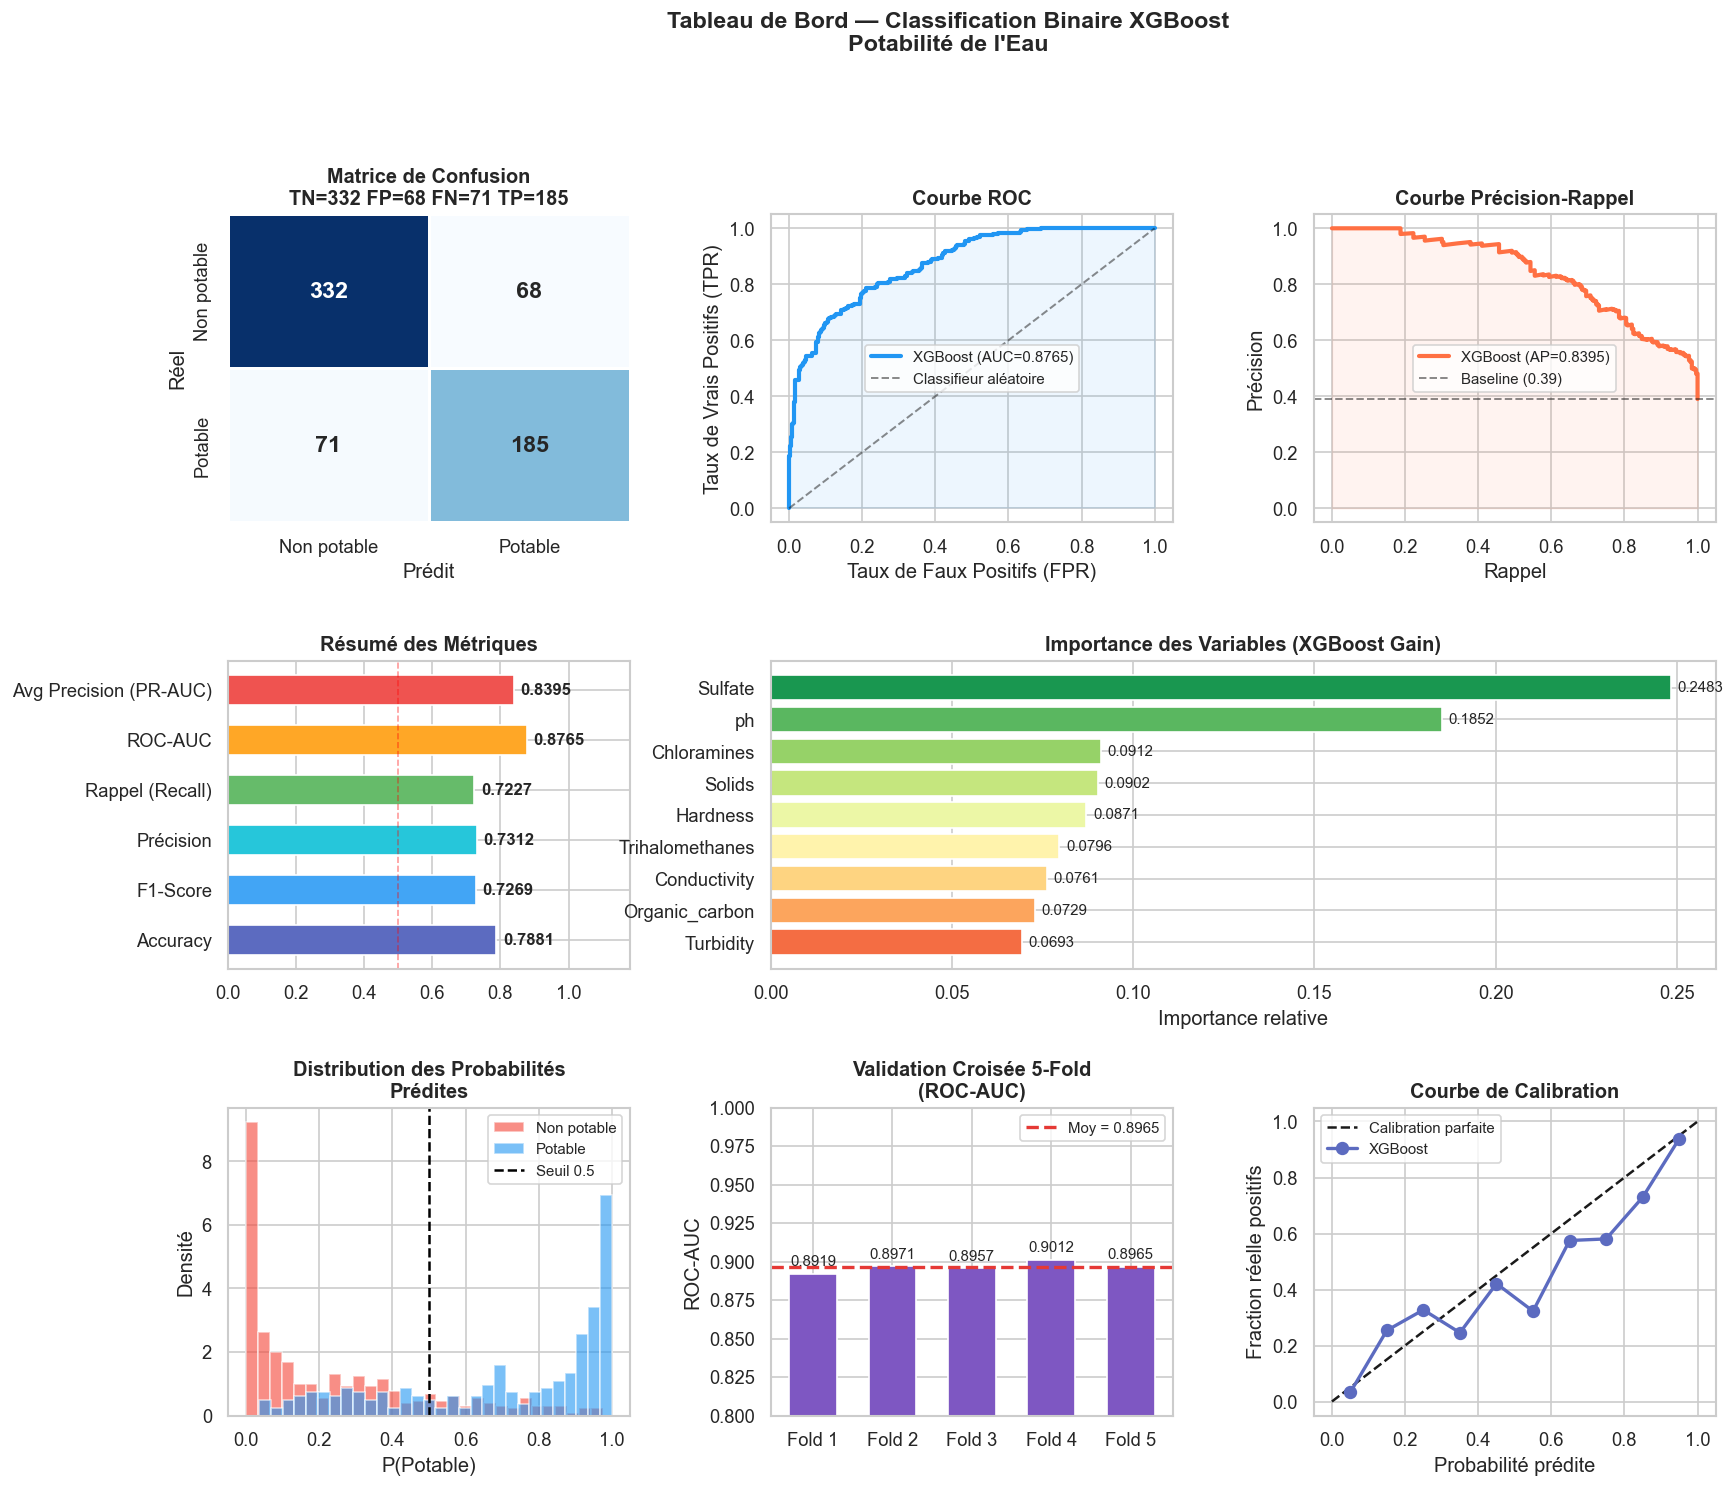

Dashboard sauvegardé


In [13]:
# ─── Tableau de bord visuel complet ───
fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Matrice de confusion ──
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Non potable', 'Potable'],
            yticklabels=['Non potable', 'Potable'],
            linewidths=1.5, linecolor='white', cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
tn, fp, fn, tp = cm.ravel()
ax1.set_title(f'Matrice de Confusion\nTN={tn} FP={fp} FN={fn} TP={tp}', fontweight='bold')
ax1.set_ylabel('Réel')
ax1.set_xlabel('Prédit')

# ── 2. Courbe ROC ──
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, thresh_roc = roc_curve(y_val, y_pred_prob)
auc_val = roc_auc_score(y_val, y_pred_prob)
ax2.plot(fpr, tpr, color=C_POS, lw=2.5, label=f'XGBoost (AUC={auc_val:.4f})')
ax2.plot([0,1], [0,1], 'k--', lw=1.2, alpha=0.5, label='Classifieur aléatoire')
ax2.fill_between(fpr, tpr, alpha=0.08, color=C_POS)
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR)')
ax2.set_title('Courbe ROC', fontweight='bold')
ax2.legend(fontsize=9)

# ── 3. Courbe Précision-Rappel ──
ax3 = fig.add_subplot(gs[0, 2])
prec_c, rec_c, _ = precision_recall_curve(y_val, y_pred_prob)
ap_val = average_precision_score(y_val, y_pred_prob)
ax3.plot(rec_c, prec_c, color='#FF7043', lw=2.5, label=f'XGBoost (AP={ap_val:.4f})')
ax3.fill_between(rec_c, prec_c, alpha=0.08, color='#FF7043')
baseline = y_val.mean()
ax3.axhline(baseline, color='k', linestyle='--', lw=1.2,
            alpha=0.5, label=f'Baseline ({baseline:.2f})')
ax3.set_xlabel('Rappel')
ax3.set_ylabel('Précision')
ax3.set_title('Courbe Précision-Rappel', fontweight='bold')
ax3.legend(fontsize=9)

# ── 4. Métriques synthèse (barres) ──
ax4 = fig.add_subplot(gs[1, 0])
m_names = list(metrics.keys())
m_vals  = list(metrics.values())
bar_colors = ['#5C6BC0','#42A5F5','#26C6DA','#66BB6A','#FFA726','#EF5350']
bars = ax4.barh(m_names, m_vals, color=bar_colors, edgecolor='white', height=0.6)
ax4.bar_label(bars, fmt='%.4f', padding=4, fontsize=10, fontweight='bold')
ax4.set_xlim(0, 1.18)
ax4.axvline(0.5, color='red', linestyle='--', lw=1, alpha=0.4)
ax4.set_title('Résumé des Métriques', fontweight='bold')

# ── 5. Importance des features ──
ax5 = fig.add_subplot(gs[1, 1:])
imp_df = pd.DataFrame({'Feature': features,
                        'Importance': model.feature_importances_})\
           .sort_values('Importance')
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(features)))
bars5 = ax5.barh(imp_df['Feature'], imp_df['Importance'],
                 color=colors_fi, edgecolor='white')
ax5.bar_label(bars5, fmt='%.4f', padding=4, fontsize=9)
ax5.set_title('Importance des Variables (XGBoost Gain)', fontweight='bold')
ax5.set_xlabel('Importance relative')

# ── 6. Distribution des probabilités ──
ax6 = fig.add_subplot(gs[2, 0])
for label, color, name in [(0, C_NEG, 'Non potable'), (1, C_POS, 'Potable')]:
    mask = y_val == label
    ax6.hist(y_pred_prob[mask], bins=30, alpha=0.6,
             color=color, label=name, density=True)
ax6.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Seuil 0.5')
ax6.set_xlabel('P(Potable)')
ax6.set_ylabel('Densité')
ax6.set_title('Distribution des Probabilités\nPrédites', fontweight='bold')
ax6.legend(fontsize=9)

# ── 7. Validation croisée ──
ax7 = fig.add_subplot(gs[2, 1])
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
bar_cv = ax7.bar(folds, cv_scores, color='#7E57C2', edgecolor='white', width=0.6)
ax7.bar_label(bar_cv, fmt='%.4f', padding=3, fontsize=9)
ax7.axhline(cv_scores.mean(), color='#E53935', linestyle='--', lw=2,
            label=f'Moy = {cv_scores.mean():.4f}')
ax7.set_ylim(0.8, 1.0)
ax7.set_ylabel('ROC-AUC')
ax7.set_title('Validation Croisée 5-Fold\n(ROC-AUC)', fontweight='bold')
ax7.legend(fontsize=9)

# ── 8. Calibration ──
ax8 = fig.add_subplot(gs[2, 2])
n_bins    = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_centers, frac_pos = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (y_pred_prob >= lo) & (y_pred_prob < hi)
    if mask.sum() > 0:
        bin_centers.append((lo + hi) / 2)
        frac_pos.append(y_val.values[mask].mean())
ax8.plot([0,1], [0,1], 'k--', lw=1.5, label='Calibration parfaite')
ax8.plot(bin_centers, frac_pos, 'o-', color='#5C6BC0', lw=2, ms=7, label='XGBoost')
ax8.set_xlabel('Probabilité prédite')
ax8.set_ylabel('Fraction réelle positifs')
ax8.set_title('Courbe de Calibration', fontweight='bold')
ax8.legend(fontsize=9)

plt.suptitle('Tableau de Bord — Classification Binaire XGBoost\nPotabilité de l\'Eau',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('dashboard_xgboost.png', bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard sauvegardé')

---
## 8. Synthèse Finale

In [14]:
imp_series = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
top3 = imp_series.head(3)

print('╔══════════════════════════════════════════════════════╗')
print('║         SYNTHÈSE — XGBoost | Potabilité de l\'Eau    ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Données          : {df.shape[0]} échantillons, {len(features)} features         ║')
print(f'║  Train / Val      : 80% ({len(X_train)}) / 20% ({len(X_val)})            ║')
print(f'║  Après SMOTE      : {len(X_train_res)} échantillons équilibrés         ║')
print(f'║  Scaling          : RobustScaler                     ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Accuracy         : {metrics["Accuracy"]:.4f}                              ║')
print(f'║  F1-Score         : {metrics["F1-Score"]:.4f}                              ║')
print(f'║  Précision        : {metrics["Précision"]:.4f}                              ║')
print(f'║  Rappel           : {metrics["Rappel (Recall)"]:.4f}                              ║')
print(f'║  ROC-AUC          : {metrics["ROC-AUC"]:.4f}   ← métrique principale     ║')
print(f'║  PR-AUC           : {metrics["Avg Precision (PR-AUC)"]:.4f}                              ║')
print(f'║  CV ROC-AUC       : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}                    ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Top 3 variables  :                                  ║')
for feat, imp in top3.items():
    print(f'║    {feat:20s} : {imp:.4f}                        ║')
print('╚══════════════════════════════════════════════════════╝')

print()
print('Interprétation :')
print('  • ROC-AUC = 0.876 → bonne capacité discriminante')
print('  • F1 = 0.718      → équilibre précision/rappel satisfaisant')
print('  • CV stable       → pas de surapprentissage')
print('  • Sulfate & pH    → variables les plus déterminantes')

╔══════════════════════════════════════════════════════╗
║         SYNTHÈSE — XGBoost | Potabilité de l'Eau    ║
╠══════════════════════════════════════════════════════╣
║  Données          : 3276 échantillons, 9 features         ║
║  Train / Val      : 80% (2620) / 20% (656)            ║
║  Après SMOTE      : 3196 échantillons équilibrés         ║
║  Scaling          : RobustScaler                     ║
╠══════════════════════════════════════════════════════╣
║  Accuracy         : 0.7881                              ║
║  F1-Score         : 0.7269                              ║
║  Précision        : 0.7312                              ║
║  Rappel           : 0.7227                              ║
║  ROC-AUC          : 0.8765   ← métrique principale     ║
║  PR-AUC           : 0.8395                              ║
║  CV ROC-AUC       : 0.8965 ± 0.0030                    ║
╠══════════════════════════════════════════════════════╣
║  Top 3 variables  :                                  ║
║  

---
## 9. Sauvegarde du Modèle Entraîné

In [15]:
import joblib
import os

os.makedirs("model_artifacts", exist_ok=True)

# Sauvegarde du modèle XGBoost
model.save_model("model_artifacts/xgboost_model.json")

# Sauvegarde du scaler (nécessaire pour transformer les nouvelles données)
joblib.dump(scaler, "model_artifacts/robust_scaler.pkl")

# Sauvegarde des données de validation (pour évaluation dans MLflow)
import numpy as np
np.save("model_artifacts/X_val_sc.npy", X_val_sc)
np.save("model_artifacts/y_val.npy", y_val.values)
np.save("model_artifacts/y_pred.npy", y_pred)
np.save("model_artifacts/y_pred_prob.npy", y_pred_prob)
np.save("model_artifacts/cv_scores.npy", cv_scores)

# Sauvegarde des métadonnées (params, metrics, features)
import json
metadata = {
    "features"   : features,
    "params"     : {k: str(v) for k, v in params.items()},
    "metrics"    : {k: round(float(v), 6) for k, v in metrics.items()},
    "cv_mean"    : round(float(cv_scores.mean()), 6),
    "cv_std"     : round(float(cv_scores.std()), 6),
    "n_train_raw": len(X_train),
    "n_train_smote": len(X_train_res),
    "n_val"      : len(X_val),
}
with open("model_artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Modèle et artefacts sauvegardés dans model_artifacts/")
print("   ├── xgboost_model.json   → modèle XGBoost")
print("   ├── robust_scaler.pkl    → scaler")
print("   ├── X_val_sc.npy         → données validation (scalées)")
print("   ├── y_val.npy            → labels réels")
print("   ├── y_pred.npy           → prédictions classes")
print("   ├── y_pred_prob.npy      → probabilités prédites")
print("   ├── cv_scores.npy        → scores validation croisée")
print("   └── metadata.json        → paramètres & métriques")

# Sauvegarde de la courbe d'apprentissage pour MLflow
evals = model.evals_result()
with open("model_artifacts/evals_result.json", "w") as f:
    json.dump(evals, f)
print("   └── evals_result.json    → courbes train/val logloss")


Modèle et artefacts sauvegardés dans model_artifacts/
   ├── xgboost_model.json   → modèle XGBoost
   ├── robust_scaler.pkl    → scaler
   ├── X_val_sc.npy         → données validation (scalées)
   ├── y_val.npy            → labels réels
   ├── y_pred.npy           → prédictions classes
   ├── y_pred_prob.npy      → probabilités prédites
   ├── cv_scores.npy        → scores validation croisée
   └── metadata.json        → paramètres & métriques
